# Outspark: grafo histórico de Facebook

Este cuaderno reproduce el grafo completo de amistades y un subgrafo de la red Facebook New Orleans. Los datos proceden del [conjunto WOSN 2009 de MPI-SWS](https://socialnetworks.mpi-sws.org/data-wosn2009.html).

Al ejecutar las celdas en Google Colab, los dos archivos originales se descargan de MPI-SWS y se comprueban mediante SHA-256. Las amistades describen conexiones históricas; las publicaciones en muros no identifican cadenas de republicación. Las figuras que aparecen guardadas en esta copia corresponden a una ejecución anterior y pueden regenerarse.


In [ ]:
"""Audita y visualiza el grafo Facebook New Orleans de MPI-SWS.

Entrada: facebook-links.txt.gz y facebook-wall.txt.gz originales.
Las amistades se convierten en aristas no dirigidas; cada publicación de muro
mantiene el sentido autor -> dueño del muro y su marca temporal.
"""

from __future__ import annotations

import argparse
import gzip
import hashlib
import json
import math
import shutil
import subprocess
from collections import deque
from datetime import datetime, timezone
from pathlib import Path


def lines(path: Path):
    opener = gzip.open if path.suffix == ".gz" else open
    with opener(path, "rt", encoding="ascii") as stream:
        for number, raw in enumerate(stream, start=1):
            row = raw.rstrip("\r\n").split("\t")
            if len(row) != 3:
                raise ValueError(f"{path.name}:{number}: se esperaban 3 columnas")
            try:
                first, second = int(row[0]), int(row[1])
                stamp = None if row[2] == r"\N" else int(row[2])
            except ValueError as exc:
                raise ValueError(f"{path.name}:{number}: valor inválido") from exc
            yield first, second, stamp


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def date_utc(stamp: int | None) -> str | None:
    if stamp is None:
        return None
    return datetime.fromtimestamp(stamp, timezone.utc).strftime("%Y-%m-%d")


def load_friendships(path: Path):
    adjacency: dict[int, set[int]] = {}
    rows = edges = loops = timestamps = 0
    first_time = last_time = None
    for owner, friend, stamp in lines(path):
        rows += 1
        adjacency.setdefault(owner, set())
        adjacency.setdefault(friend, set())
        if owner == friend:
            loops += 1
            continue
        if friend not in adjacency[owner]:
            adjacency[owner].add(friend)
            adjacency[friend].add(owner)
            edges += 1
        if stamp is not None:
            timestamps += 1
            first_time = stamp if first_time is None else min(first_time, stamp)
            last_time = stamp if last_time is None else max(last_time, stamp)
    return adjacency, {
        "filas_amistad_dirigidas": rows,
        "aristas_amistad_no_dirigidas_unicas": edges,
        "filas_lazo": loops,
        "filas_con_fecha_amistad": timestamps,
        "primera_amistad_utc": date_utc(first_time),
        "ultima_amistad_utc": date_utc(last_time),
    }


def load_wall_posts(path: Path):
    owners: set[int] = set()
    authors: set[int] = set()
    self_posts = rows = 0
    first_time = last_time = None
    for owner, author, stamp in lines(path):
        if stamp is None:
            raise ValueError("Una publicación de muro carece de fecha")
        rows += 1
        owners.add(owner)
        authors.add(author)
        self_posts += owner == author
        first_time = stamp if first_time is None else min(first_time, stamp)
        last_time = stamp if last_time is None else max(last_time, stamp)
    return authors, {
        "filas_publicaciones_muro": rows,
        "autores_distintos": len(authors),
        "duenos_muro_distintos": len(owners),
        "usuarios_muro_distintos": len(authors | owners),
        "publicaciones_muro_propio": self_posts,
        "primera_publicacion_utc": date_utc(first_time),
        "ultima_publicacion_utc": date_utc(last_time),
        "direccion": "segunda columna (autor) -> primera columna (dueño del muro)",
    }, owners | authors


def components(adjacency: dict[int, set[int]]):
    unseen = set(adjacency)
    sizes = []
    while unseen:
        start = min(unseen)
        unseen.remove(start)
        queue = deque([start])
        size = 0
        while queue:
            current = queue.popleft()
            size += 1
            for neighbor in adjacency[current]:
                if neighbor in unseen:
                    unseen.remove(neighbor)
                    queue.append(neighbor)
        sizes.append(size)
    return sorted(sizes, reverse=True)


def reach_by_hops(adjacency: dict[int, set[int]], seed: int, max_hops: int = 3):
    if seed not in adjacency:
        raise ValueError(f"El usuario {seed} no aparece en las amistades")
    seen = {seed}
    frontier = {seed}
    rounds = []
    for hop in range(1, max_hops + 1):
        following = set()
        for user in frontier:
            following.update(adjacency[user] - seen)
        seen.update(following)
        rounds.append({"saltos": hop, "nuevos": len(following), "acumulados_sin_semilla": len(seen) - 1})
        frontier = following
    return rounds


def draw_subgraph(adjacency: dict[int, set[int]], authors: set[int], seed: int, output: Path, limit: int):
    # La figura es un subgrafo inducido, no una muestra que sustituya la red completa.
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import networkx as nx

    neighbors = sorted(adjacency[seed], key=lambda user: (-len(adjacency[user]), user))[: limit - 1]
    selected = [seed, *neighbors]
    selected_set = set(selected)
    graph = nx.Graph()
    graph.add_nodes_from(selected)
    for user in selected:
        for friend in adjacency[user] & selected_set:
            if user < friend:
                graph.add_edge(user, friend)
    positions = nx.spring_layout(graph, seed=7, iterations=120)
    colors = ["#C62828" if user == seed else "#2679A8" if user in authors else "#AAB8C2" for user in graph]
    sizes = [260 if user == seed else 55 + min(len(adjacency[user]), 400) * 0.32 for user in graph]
    fig, ax = plt.subplots(figsize=(9, 5.3), dpi=170)
    fig.patch.set_facecolor("white")
    nx.draw_networkx_edges(graph, positions, ax=ax, width=0.65, edge_color="#B8C2CC", alpha=0.60)
    nx.draw_networkx_nodes(graph, positions, ax=ax, node_color=colors, node_size=sizes, linewidths=0.5, edgecolors="white")
    labels = {user: str(user) for user in selected[:7]}
    nx.draw_networkx_labels(graph, positions, labels, ax=ax, font_size=7, font_color="#1C2730")
    ax.set_title(f"Subgrafo de amistades de Facebook: {graph.number_of_nodes()} usuarios y {graph.number_of_edges()} relaciones", fontsize=11)
    ax.text(0.5, -0.03, "Rojo: usuario de referencia  ·  Azul: autor de publicaciones en muros  ·  Gris: sin autoría registrada", transform=ax.transAxes, ha="center", fontsize=7)
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(output, bbox_inches="tight")
    plt.close(fig)
    return {"nodos": graph.number_of_nodes(), "aristas": graph.number_of_edges(), "semilla": seed, "criterio": f"semilla y {len(neighbors)} vecinos con mayor grado"}


def draw_full_graph(adjacency: dict[int, set[int]], output: Path):
    """Dibuja cada nodo y cada amistad con Graphviz sfdp (sin muestreo)."""
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.collections import LineCollection

    executable = shutil.which("sfdp")
    if executable is None:
        raise RuntimeError("Se requiere Graphviz sfdp para dibujar el grafo completo")
    dot = output.with_suffix(".dot")
    edges = 0
    with dot.open("w", encoding="ascii") as stream:
        stream.write('graph Facebook {\n  graph [layout=sfdp, overlap=true, outputorder=edgesfirst, bgcolor="white", dpi=160, size="12,8!", margin=0.02, start=7];\n')
        stream.write('  node [shape=point, width=0.012, label="", color="#1376A9D8"];\n')
        stream.write('  edge [color="#31536D0A", penwidth=0.12];\n')
        for user in sorted(adjacency):
            stream.write(f"  {user};\n")
        for user in sorted(adjacency):
            for friend in sorted(adjacency[user]):
                if user < friend:
                    stream.write(f"  {user} -- {friend};\n")
                    edges += 1
        stream.write("}\n")
    plain = output.with_suffix(".plain")
    try:
        with plain.open("w", encoding="ascii") as stream:
            subprocess.run([executable, "-Tplain", str(dot)], stdout=stream, check=True, timeout=300)
        positions = {}
        with plain.open("r", encoding="ascii") as stream:
            for line in stream:
                if line.startswith("node "):
                    parts = line.split()
                    positions[int(parts[1])] = (float(parts[2]), float(parts[3]))
    finally:
        plain.unlink(missing_ok=True)
    if len(positions) != len(adjacency):
        raise RuntimeError(f"sfdp devolvió {len(positions)} posiciones para {len(adjacency)} nodos")

    # La componente principal ocupa casi toda la figura. Las demás se ordenan
    # en dos filas, manteniendo todos sus nodos y relaciones dentro del dibujo.
    unseen = set(adjacency)
    groups = []
    while unseen:
        start = min(unseen)
        unseen.remove(start)
        queue = deque([start])
        group = []
        while queue:
            user = queue.popleft()
            group.append(user)
            for friend in adjacency[user]:
                if friend in unseen:
                    unseen.remove(friend)
                    queue.append(friend)
        groups.append(group)
    groups.sort(key=lambda group: (-len(group), min(group)))
    main_group = groups[0]
    xs = np.array([positions[user][0] for user in main_group])
    ys = np.array([positions[user][1] for user in main_group])
    x_min, x_max = float(xs.min()), float(xs.max())
    y_min, y_max = float(ys.min()), float(ys.max())
    mapped = {}
    for user in main_group:
        x, y = positions[user]
        mapped[user] = (0.04 + (x - x_min) / max(1, x_max - x_min) * 0.92,
                        0.19 + (y - y_min) / max(1, y_max - y_min) * 0.76)
    for index, group in enumerate(groups[1:]):
        column, row = index % 72, index // 72
        center_x = 0.012 + column * (0.976 / 71)
        center_y = 0.055 + row * 0.055
        for offset, user in enumerate(sorted(group)):
            angle = 2 * math.pi * offset / max(1, len(group))
            mapped[user] = (center_x + 0.0038 * math.cos(angle), center_y + 0.0048 * math.sin(angle))

    segments = np.empty((edges, 2, 2), dtype=np.float32)
    index = 0
    for user in sorted(adjacency):
        for friend in sorted(adjacency[user]):
            if user < friend:
                segments[index, 0] = mapped[user]
                segments[index, 1] = mapped[friend]
                index += 1
    if index != edges:
        raise RuntimeError("El número de aristas dibujadas no coincide")
    fig, ax = plt.subplots(figsize=(12, 8), dpi=180)
    fig.patch.set_facecolor("white")
    ax.add_collection(LineCollection(segments, colors=[(0.10, 0.26, 0.40, 0.022)], linewidths=0.10, rasterized=True))
    main_points = np.array([mapped[user] for user in main_group])
    ax.scatter(main_points[:, 0], main_points[:, 1], s=0.45, c="#1676A5", alpha=0.52, linewidths=0, rasterized=True)
    minor_points = np.array([mapped[user] for group in groups[1:] for user in group])
    ax.scatter(minor_points[:, 0], minor_points[:, 1], s=1.8, c="#D45B38", alpha=0.82, linewidths=0, rasterized=True)
    ax.text(0.5, 0.013, f"Componente mayor: {len(main_group):,} usuarios · Otras {len(groups)-1} componentes: {len(adjacency)-len(main_group)} usuarios".replace(",", " "), ha="center", va="center", fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    fig.tight_layout(pad=0.15)
    fig.savefig(output, facecolor="white")
    plt.close(fig)
    return {"tipo": "grafo de nodos y aristas", "nodos": len(adjacency), "aristas_dibujadas": edges, "layout": "Graphviz sfdp para la componente mayor; componentes menores dispuestas en dos filas", "sin_muestreo": True, "archivo_dot": dot.name}


def export_full_edge_list(adjacency: dict[int, set[int]], output: Path):
    """Escribe el grafo íntegro en formato CSV comprimido para reproducirlo."""
    with gzip.open(output, "wt", encoding="ascii") as stream:
        stream.write("usuario_1,usuario_2\n")
        for user in sorted(adjacency):
            for friend in sorted(adjacency[user]):
                if user < friend:
                    stream.write(f"{user},{friend}\n")


def analyze(links: Path, wall: Path, output: Path, seed: int, figure_nodes: int):
    output.mkdir(parents=True, exist_ok=True)
    adjacency, link_stats = load_friendships(links)
    authors, wall_stats, wall_users = load_wall_posts(wall)
    sizes = components(adjacency)
    degrees = sorted(((len(friends), user) for user, friends in adjacency.items()), reverse=True)
    full_figure = draw_full_graph(adjacency, output / "grafo_completo_facebook.png")
    export_full_edge_list(adjacency, output / "aristas_amistad_completa.csv.gz")
    figure = draw_subgraph(adjacency, authors, seed, output / "subgrafo_facebook.png", figure_nodes)
    result = {
        "fuente": "MPI-SWS, Facebook New Orleans, WOSN 2009",
        "archivos": {links.name: sha256(links), wall.name: sha256(wall)},
        "amistades": {
            **link_stats,
            "usuarios_nodos": len(adjacency),
            "componentes_conexas": len(sizes),
            "componente_mayor": sizes[0],
            "cinco_componentes_mayores": sizes[:5],
            "grado_maximo": degrees[0][0],
            "usuario_grado_maximo": degrees[0][1],
            "usuarios_sin_aristas_en_archivo": sum(not friends for friends in adjacency.values()),
            "observacion": "La lista de enlaces no enumera usuarios sin aparición en una arista.",
        },
        "muro": {**wall_stats, "usuarios_muro_presentes_en_amistades": len(wall_users & adjacency.keys())},
        "bfs": {"semilla": seed, "rondas": reach_by_hops(adjacency, seed)},
        "figura_completa": full_figure,
        "figura": figure,
        "limite_interpretacion": "No hay ID de publicación, contenido ni trazas de republicación: no se pueden reconstruir cadenas históricas de compartidos.",
    }
    destination = output / "estadisticas_facebook.json"
    destination.write_text(json.dumps(result, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    print(json.dumps({"nodos": len(adjacency), "aristas": link_stats["aristas_amistad_no_dirigidas_unicas"], "publicaciones_muro": wall_stats["filas_publicaciones_muro"], "estadisticas": str(destination), "grafo_completo": str(output / "grafo_completo_facebook.png"), "subgrafo": str(output / "subgrafo_facebook.png")}, ensure_ascii=False))
    return result


def main(argv=None):
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--links", type=Path, default=Path("facebook-links.txt.gz"))
    parser.add_argument("--wall", type=Path, default=Path("facebook-wall.txt.gz"))
    parser.add_argument("--out", type=Path, default=Path("salida_facebook"))
    parser.add_argument("--seed", type=int, default=1)
    parser.add_argument("--figure-nodes", type=int, default=45)
    args = parser.parse_args(argv)
    if args.figure_nodes < 2:
        parser.error("--figure-nodes debe ser al menos 2")
    return analyze(args.links, args.wall, args.out, args.seed, args.figure_nodes)




In [ ]:
from pathlib import Path
from urllib.request import urlopen
import hashlib

archivos = {
    'facebook-links.txt.gz': '32d149f76c3421a08b03bfc629a9de6ce65b6fa56272cd9d5424e3de5b1acff2',
    'facebook-wall.txt.gz': 'c4449336e346061068b8278d09176b195b3f132f6d6fe50adbc5730938496dca',
}
base = 'https://socialnetworks.mpi-sws.org/data/'
for nombre, sha_esperado in archivos.items():
    ruta = Path(nombre)
    if not ruta.is_file() or hashlib.sha256(ruta.read_bytes()).hexdigest() != sha_esperado:
        temporal = ruta.with_suffix(ruta.suffix + '.descarga')
        with urlopen(base + nombre, timeout=120) as origen, temporal.open('wb') as destino:
            while bloque := origen.read(1024 * 1024):
                destino.write(bloque)
        if hashlib.sha256(temporal.read_bytes()).hexdigest() != sha_esperado:
            temporal.unlink(missing_ok=True)
            raise ValueError(f'La descarga de {nombre} no coincide con el archivo analizado')
        temporal.replace(ruta)
    print(f'Datos verificados: {nombre}')

resultado = main([
    '--links', 'facebook-links.txt.gz',
    '--wall', 'facebook-wall.txt.gz',
    '--out', 'salida_facebook',
])


{"nodos": 63731, "aristas": 817090, "publicaciones_muro": 876993, "estadisticas": "salida_facebook/estadisticas_facebook.json", "grafo_completo": "salida_facebook/grafo_completo_facebook.png", "subgrafo": "salida_facebook/subgrafo_facebook.png"}


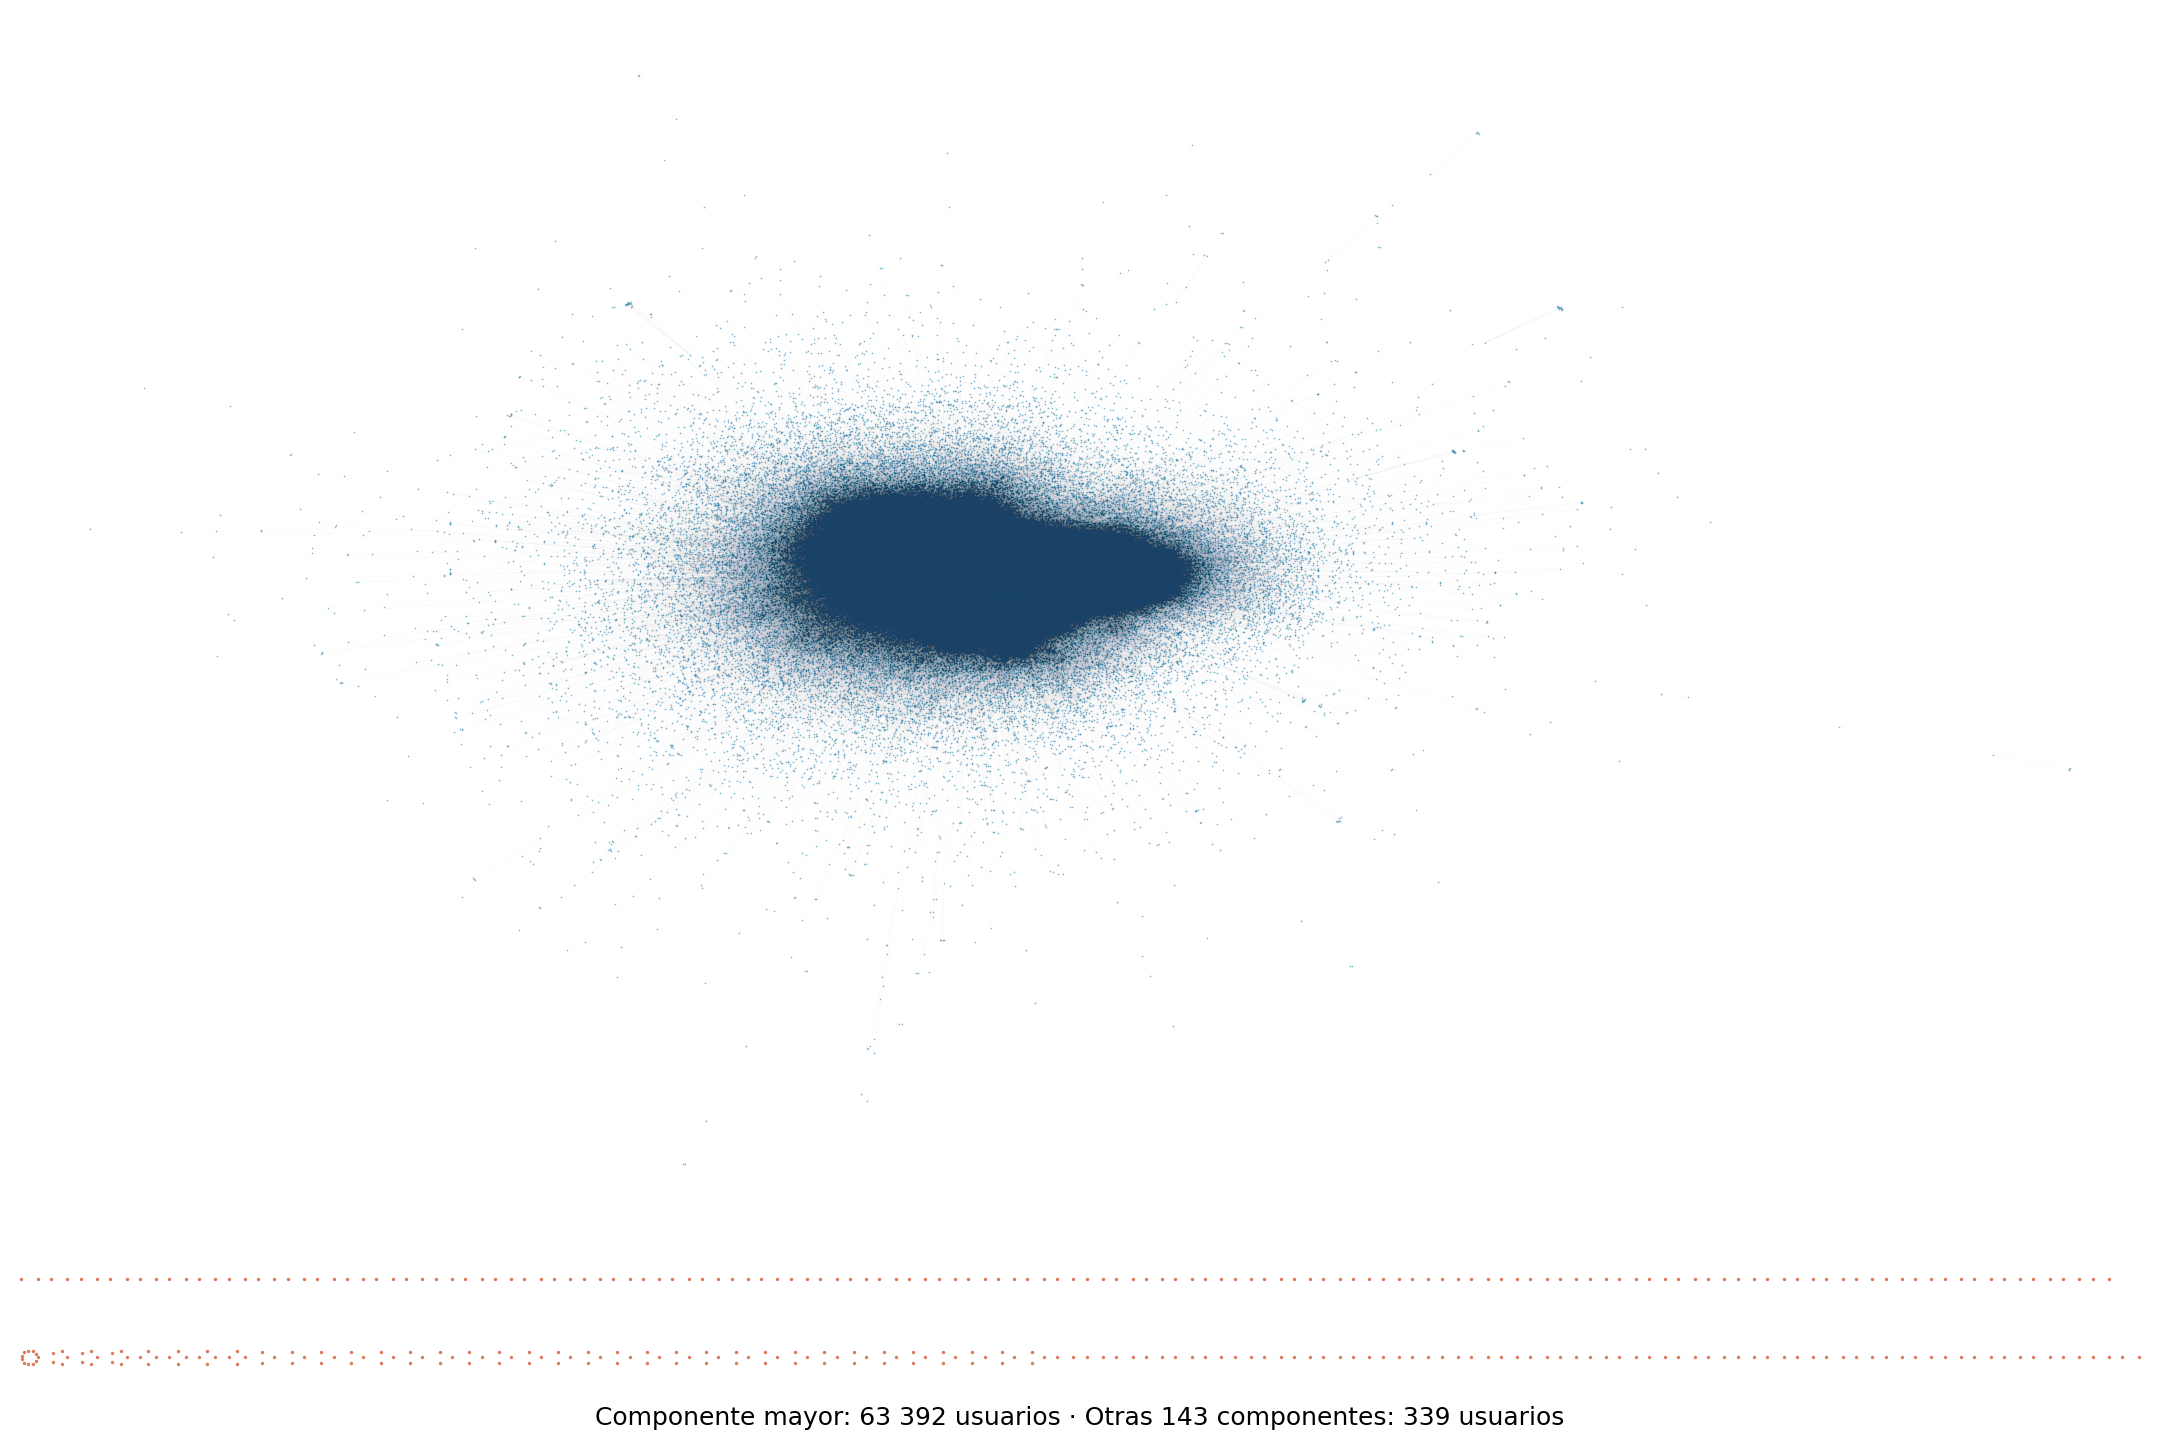

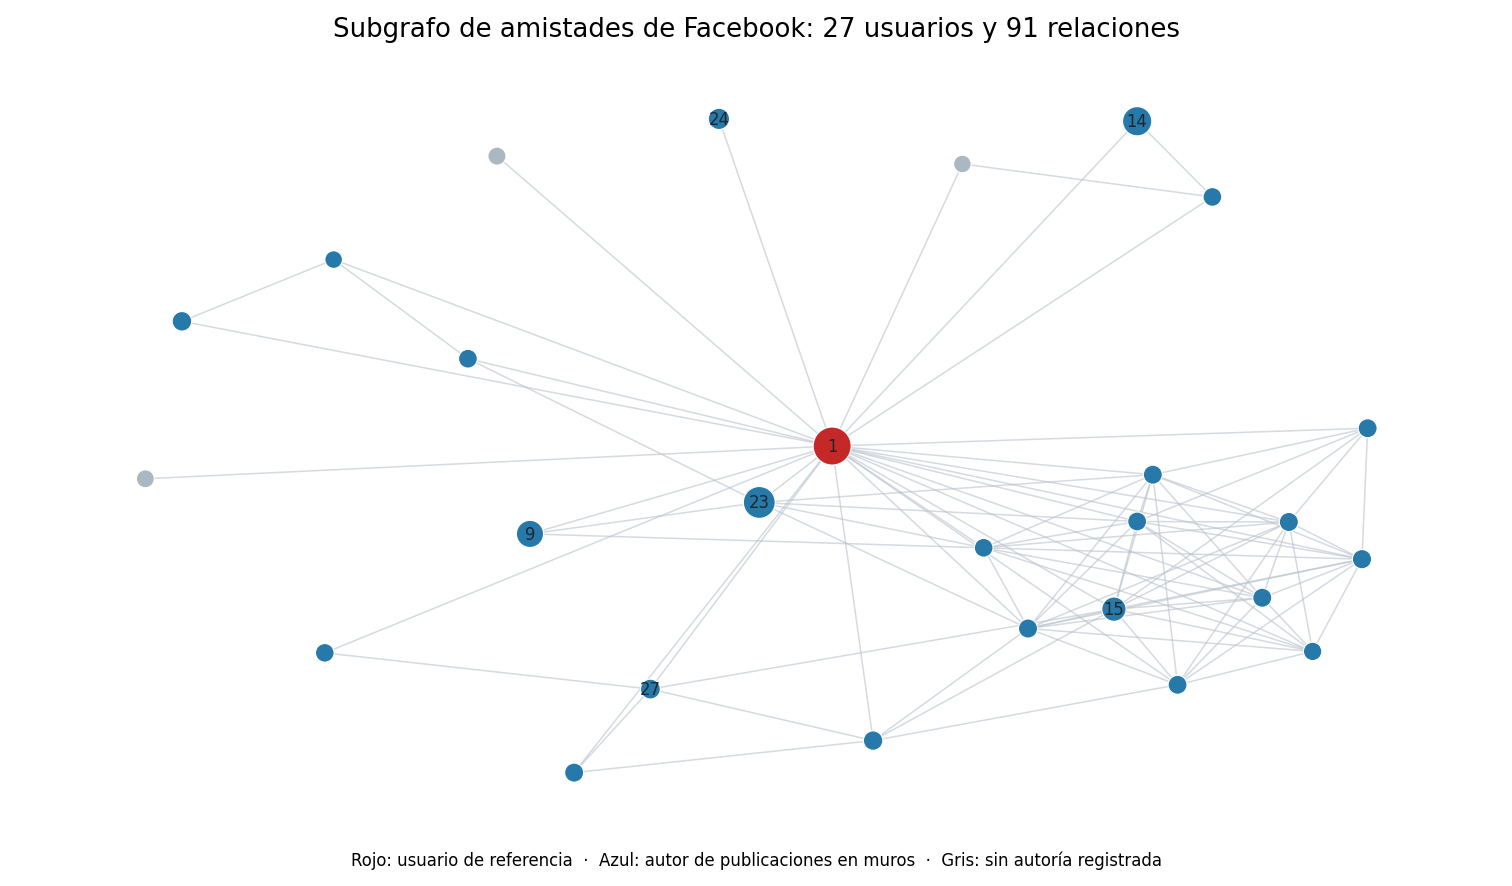

In [ ]:
from IPython.display import Image, display
display(Image(filename="salida_facebook/grafo_completo_facebook.png"))
display(Image(filename="salida_facebook/subgrafo_facebook.png"))
